New York City - East River Bicycle Crossings data setini kullanarak önce datamıza eda yaptık ardından lineer resgresyon ile eğittik

In [268]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [269]:
df=pd.read_csv("nyc-east-river-bicycle-counts.csv")

In [270]:
df.head()

,Unnamed: 0,Date,Day,High Temp (°F),Low Temp (°F),Precipitation,Brooklyn Bridge,Manhattan Bridge,Williamsburg Bridge,Queensboro Bridge,Total
0,0,2016-04-01 00:00:00,2016-04-01 00:00:00,78.1,66.0,0.01,1704.0,3126,4115.0,2552.0,11497
1,1,2016-04-02 00:00:00,2016-04-02 00:00:00,55.0,48.9,0.15,827.0,1646,2565.0,1884.0,6922
2,2,2016-04-03 00:00:00,2016-04-03 00:00:00,39.9,34.0,0.09,526.0,1232,1695.0,1306.0,4759
3,3,2016-04-04 00:00:00,2016-04-04 00:00:00,44.1,33.1,0.47 (S),521.0,1067,1440.0,1307.0,4335
4,4,2016-04-05 00:00:00,2016-04-05 00:00:00,42.1,26.1,0,1416.0,2617,3081.0,2357.0,9471


In [271]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           210 non-null    int64  
 1   Date                 210 non-null    str    
 2   Day                  210 non-null    str    
 3   High Temp (°F)       210 non-null    float64
 4   Low Temp (°F)        210 non-null    float64
 5   Precipitation        210 non-null    str    
 6   Brooklyn Bridge      210 non-null    float64
 7   Manhattan Bridge     210 non-null    int64  
 8   Williamsburg Bridge  210 non-null    float64
 9   Queensboro Bridge    210 non-null    float64
 10  Total                210 non-null    int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 18.2 KB


In [272]:
df=df.drop("Date",axis=1)  #day ve date aynı değeri tuttuğu için datei sildim
df=df.drop("Unnamed: 0",axis=1)

In [273]:
df.head()

,Day,High Temp (°F),Low Temp (°F),Precipitation,Brooklyn Bridge,Manhattan Bridge,Williamsburg Bridge,Queensboro Bridge,Total
0,2016-04-01 00:00:00,78.1,66.0,0.01,1704.0,3126,4115.0,2552.0,11497
1,2016-04-02 00:00:00,55.0,48.9,0.15,827.0,1646,2565.0,1884.0,6922
2,2016-04-03 00:00:00,39.9,34.0,0.09,526.0,1232,1695.0,1306.0,4759
3,2016-04-04 00:00:00,44.1,33.1,0.47 (S),521.0,1067,1440.0,1307.0,4335
4,2016-04-05 00:00:00,42.1,26.1,0,1416.0,2617,3081.0,2357.0,9471


In [274]:
df["Precipitation"].value_counts()

Precipitation
0           119
0.01         21
0.09         21
0.15          7
0.47 (S)      7
0.2           7
T             7
0.16          7
0.24          7
0.05          7
Name: count, dtype: int64

In [275]:
df['Precipitation'] = df['Precipitation'].replace('0.47 (S)', 0.47)  #bir sutundaki değerin diğeri ile değişmesini sağlar
df['Precipitation'] = df['Precipitation'].replace('T', 18)
df['Precipitation'] = df['Precipitation'].astype(float)

In [276]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Day                  210 non-null    str    
 1   High Temp (°F)       210 non-null    float64
 2   Low Temp (°F)        210 non-null    float64
 3   Precipitation        210 non-null    float64
 4   Brooklyn Bridge      210 non-null    float64
 5   Manhattan Bridge     210 non-null    int64  
 6   Williamsburg Bridge  210 non-null    float64
 7   Queensboro Bridge    210 non-null    float64
 8   Total                210 non-null    int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 14.9 KB


In [277]:
df.tail()

,Day,High Temp (°F),Low Temp (°F),Precipitation,Brooklyn Bridge,Manhattan Bridge,Williamsburg Bridge,Queensboro Bridge,Total
205,2016-04-26 00:00:00,60.1,46.9,0.24,1997.0,3520,4559.0,2929.0,13005
206,2016-04-27 00:00:00,62.1,46.9,0.00,3343.0,5606,6577.0,4388.0,19914
207,2016-04-28 00:00:00,57.9,48.0,0.00,2486.0,4152,5336.0,3657.0,15631
208,2016-04-29 00:00:00,57.0,46.9,0.05,2375.0,4178,5053.0,3348.0,14954
209,2016-04-30 00:00:00,64.0,48.0,0.00,3199.0,4952,5675.0,3606.0,17432


In [278]:
df["Day"].value_counts()

Day
2016-04-01 00:00:00    7
2016-04-02 00:00:00    7
2016-04-03 00:00:00    7
2016-04-04 00:00:00    7
2016-04-05 00:00:00    7
2016-04-06 00:00:00    7
2016-04-07 00:00:00    7
2016-04-08 00:00:00    7
2016-04-09 00:00:00    7
2016-04-10 00:00:00    7
2016-04-11 00:00:00    7
2016-04-12 00:00:00    7
2016-04-13 00:00:00    7
2016-04-14 00:00:00    7
2016-04-15 00:00:00    7
2016-04-16 00:00:00    7
2016-04-17 00:00:00    7
2016-04-18 00:00:00    7
2016-04-19 00:00:00    7
2016-04-20 00:00:00    7
2016-04-21 00:00:00    7
2016-04-22 00:00:00    7
2016-04-23 00:00:00    7
2016-04-24 00:00:00    7
2016-04-25 00:00:00    7
2016-04-26 00:00:00    7
2016-04-27 00:00:00    7
2016-04-28 00:00:00    7
2016-04-29 00:00:00    7
2016-04-30 00:00:00    7
Name: count, dtype: int64

In [279]:
df[df["Day"] == "2016-04-27 00:00:00"]

,Day,High Temp (°F),Low Temp (°F),Precipitation,Brooklyn Bridge,Manhattan Bridge,Williamsburg Bridge,Queensboro Bridge,Total
26,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914
56,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914
86,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914
116,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914
146,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914
176,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914
206,2016-04-27 00:00:00,62.1,46.9,0.0,3343.0,5606,6577.0,4388.0,19914


In [280]:
# data setinden aynı olan değerleri temizliyoruz
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
205     True
206     True
207     True
208     True
209     True
Length: 210, dtype: bool

In [281]:
df=df.drop_duplicates()

In [282]:
df.shape

(30, 9)

In [283]:
df["Day"] = pd.to_datetime(df["Day"])
df["Day"] = df["Day"].dt.day


In [284]:
df.columns = df.columns.str.replace(" ", "_")

In [285]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Day                  30 non-null     int32  
 1   High_Temp_(°F)       30 non-null     float64
 2   Low_Temp_(°F)        30 non-null     float64
 3   Precipitation        30 non-null     float64
 4   Brooklyn_Bridge      30 non-null     float64
 5   Manhattan_Bridge     30 non-null     int64  
 6   Williamsburg_Bridge  30 non-null     float64
 7   Queensboro_Bridge    30 non-null     float64
 8   Total                30 non-null     int64  
dtypes: float64(6), int32(1), int64(2)
memory usage: 2.1 KB


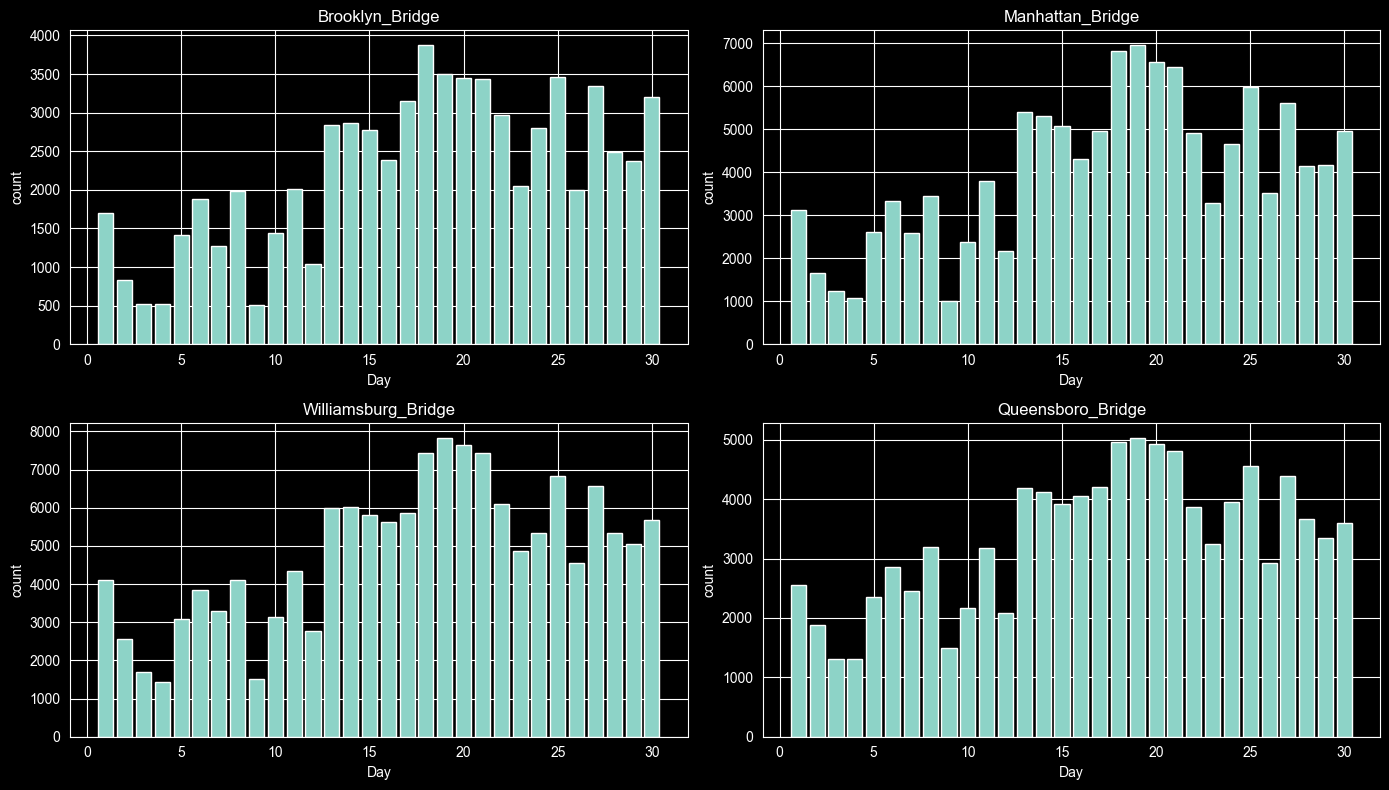

In [286]:
bridge= ["Brooklyn_Bridge","Manhattan_Bridge","Williamsburg_Bridge","Queensboro_Bridge"]
plt.figure(figsize=(14, 8))

for i, bridge in enumerate(bridge, 1):
    plt.subplot(2, 2, i)
    plt.bar(df["Day"], df[bridge])
    plt.title(bridge)
    plt.xlabel("Day")
    plt.ylabel("count")
    plt.grid(True)

plt.tight_layout()
plt.show()


LinearRegression ile gün sıcaklık ve yğış miktarına göre modeli eğitip 0.80 gibi bir doğruluk oranı elde ettik

In [287]:
X = df[
    [
        "Day",
        "High_Temp_(°F)",
        "Low_Temp_(°F)",
        "Precipitation"
    ]
]

y=(df["Total"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

regressor.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [288]:
from sklearn.metrics import mean_squared_error ,r2_score
y_pred=regressor.predict(X_test)

print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.8099932685224192
5921786.749539558
